In [ ]:
# FIX
list_darktime = [2, 20, 200, 2000, 20000]

ratio_list = []

print("Dark time (us) | Ratio")

for t in list_darktime:
    df = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t*1e-6

    t0 = polarize_pulse_width + dark_time
    t1 = t0 + 200e-9
    t2 = t1 + polarize_pulse_width - 200e-9

    reading = df[(df["Time"] >= t0) & (df["Time"] < t1)]
    # reference = df[(df["Time"] >= t1)]
    reference = df[(df["Time"] >= t1) & (df["Time"] <t2) ]

    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    ratio = reading_int / reference_int
    ratio_list.append(ratio)
    print(f" {t:13d} | {ratio:.4f}")

print(ratio_list)


Dark time (us) | Ratio
             2 | 0.0194
            20 | 0.0195
           200 | 0.0189
          2000 | 0.0153
         20000 | 0.0000
[0.019434590082047055, 0.019467104938883664, 0.01890835242982723, 0.015269299468856228, 0.0]


In [31]:
import numpy as np
import pandas as pd

# ALTERNATIVE
list_darktime = [2, 20, 200, 2000, 20000]

ratio_list = []

print("Dark time (us) | Ratio")

for t in list_darktime:
    df = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t*1e-6
    readout_window = 200e-9

    t0 = polarize_pulse_width + dark_time
    t1 = t0 + readout_window
    t2 = t1 + polarize_pulse_width/2 - readout_window
    t3 = t2 + readout_window

    reading = df[(df["Time"] >= t0) & (df["Time"] < t1)]
    # reference = df[(df["Time"] >= t1)]
    reference = df[(df["Time"] >= t2) & (df["Time"] <t3) ]

    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    ratio = reading_int / reference_int
    ratio_list.append(ratio)
    print(f" {t:13d} | {ratio:.4f}")

print(ratio_list)


Dark time (us) | Ratio
             2 | 0.9517
            20 | 0.9547
           200 | 0.9358
          2000 | 0.9590
         20000 | nan
[0.9516645235016555, 0.9547010900002273, 0.9357921250507263, 0.959006821364384, nan]


C:\Users\trina\AppData\Local\Temp\ipykernel_64084\740518523.py:31: RuntimeWarning: invalid value encountered in scalar divide
  ratio = reading_int / reference_int


In [47]:
import numpy as np
import pandas as pd

# ALTERNATIVE
list_darktime = [2, 20, 200, 2000, 20000]

ratio_list = []

print("Dark time (us) | Ratio")

for t in list_darktime:
    df = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t*1e-6
    readout_window = 200e-9

    t0 = polarize_pulse_width + dark_time
    t1 = t0 + readout_window
    t2 = polarize_pulse_width/2
    t3 = t2 + readout_window

    reading = df[(df["Time"] >= t0) & (df["Time"] < t1)]
    # reference = df[(df["Time"] >= t1)]
    reference = df[(df["Time"] >= t2) & (df["Time"] <t3) ]

    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    ratio = reading_int / reference_int
    ratio_list.append(ratio)
    print(f" {t:13d} | {ratio:.4f}")

print(ratio_list)


Dark time (us) | Ratio
             2 | 0.9521
            20 | 0.9561
           200 | 0.9382
          2000 | 0.7985
         20000 | nan
[0.9521136496683746, 0.9560755357917826, 0.9382404860390323, 0.7984946199937274, nan]


C:\Users\trina\AppData\Local\Temp\ipykernel_64084\76420258.py:31: RuntimeWarning: invalid value encountered in scalar divide
  ratio = reading_int / reference_int


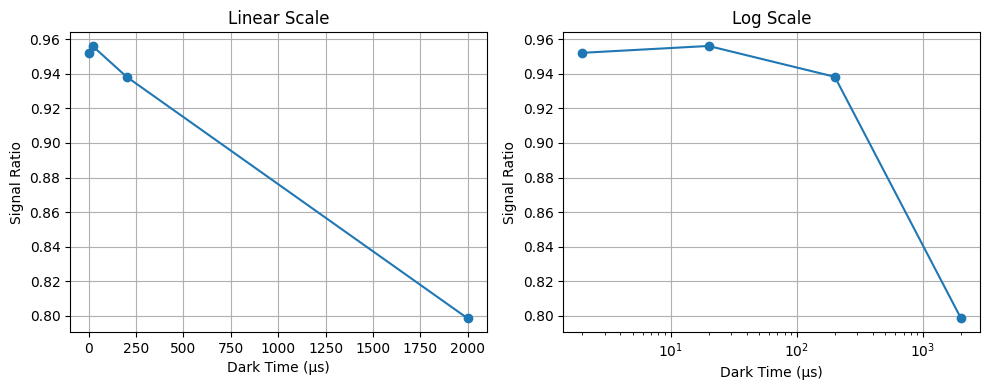

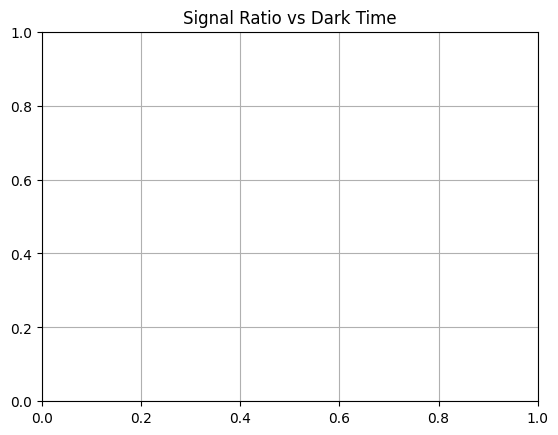

In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10,4))

# Linear scale
ax[0].plot(list_darktime, ratio_list, marker='o')
ax[0].set_xlabel("Dark Time (µs)")
ax[0].set_ylabel("Signal Ratio")
ax[0].set_title("Linear Scale")
ax[0].grid(True)

# Log scale
ax[1].plot(list_darktime, ratio_list, marker='o')
ax[1].set_xscale("log")
ax[1].set_xlabel("Dark Time (µs)")
ax[1].set_ylabel("Signal Ratio")
ax[1].set_title("Log Scale")
ax[1].grid(True)

plt.tight_layout()
plt.show()
plt.title("Signal Ratio vs Dark Time")

plt.grid(True)

plt.show()

---
# Dealing with Leading Edge and Trailing Edge

In [ ]:
import numpy as np

# considering the leading edge and trailing edge
list_darktime = [2, 20, 200, 2000, 20000] # in us
list_edge = [15e-9, 15e-9, 21e-9, 301e-9, 2e-6] # in s

ratio_list = []

print("Dark time (us) | Edge time (us) | Ratio")

for edge_index, t in enumerate(list_darktime):
    df = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t*1e-6       
    edge = list_edge[edge_index] 

    t0 = 2*edge + polarize_pulse_width + dark_time
    t1 = t0 + edge + 200e-9
    t2 = t1 + polarize_pulse_width - 200e-9 + edge

    reading = df[(df["Time"] >= t0) & (df["Time"] < t1)]
    # reference = df[(df["Time"] >= t1)]
    reference = df[(df["Time"] >= t1) & (df["Time"] <t2) ]

    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    ratio = reading_int / reference_int
    ratio_list.append(ratio)
    print(f" {t:13d} |          {edge*1e6:.3f} | {ratio:.4f}")

# print("Dark time (us) | Ratio")


Dark time (us) | Edge time (us) | Ratio
             2 |          0.015 | 0.0208
            20 |          0.015 | 0.0209
           200 |          0.021 | 0.0212
          2000 |          0.301 | 0.0454
         20000 |          2.000 | 0.1599


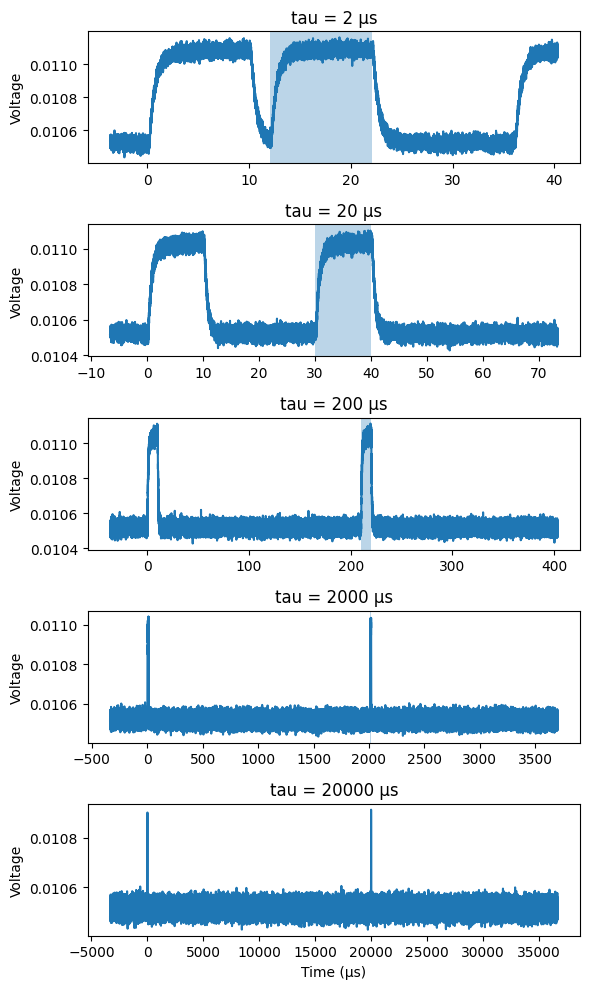

In [38]:
fig, ax = plt.subplots(len(list_darktime), 1, figsize=(6,10))

for i, t in enumerate(list_darktime):

    df = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t*1e-6
    edge = list_edge[i]

    t0 = 2*edge + polarize_pulse_width + dark_time
    t1 = t0 + edge + 200e-9
    t2 = t1 + polarize_pulse_width - 200e-9 + edge

    ax[i].plot(df["Time"]*1e6, df["Voltage"])
    ax[i].axvspan(t0*1e6, t1*1e6, alpha=0.3)
    ax[i].axvspan(t1*1e6, t2*1e6, alpha=0.3)

    ax[i].set_title(f"tau = {t} µs")
    ax[i].set_ylabel("Voltage")

ax[-1].set_xlabel("Time (µs)")
plt.tight_layout()
plt.show()

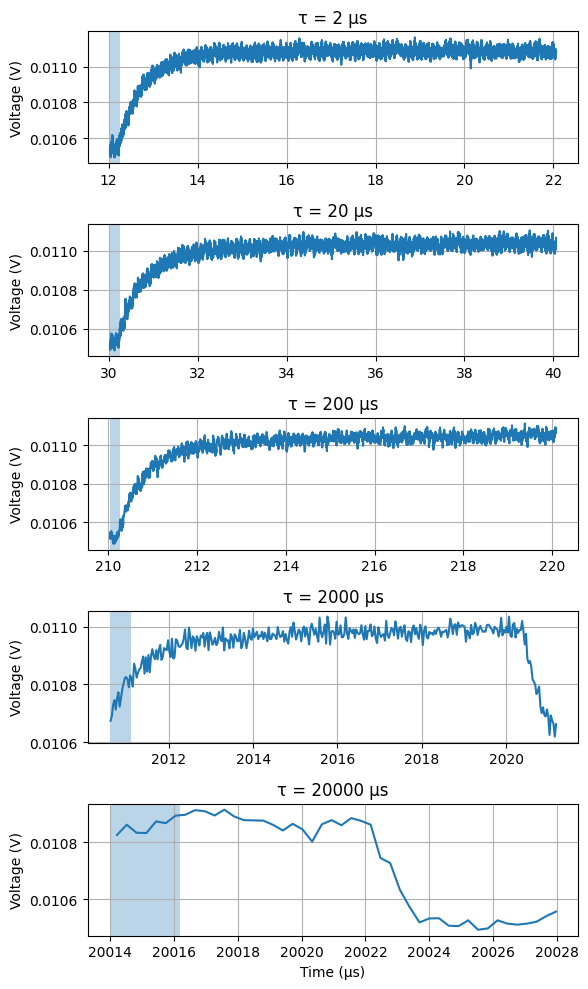

Ratios: [0.020844189061793746, 0.02092273817587092, 0.021201947910267954, 0.045373120966738616, 0.15991188320899719]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# dark times (µs)
list_darktime = [2, 20, 200, 2000, 20000]

# edge durations (seconds)
list_edge = [15e-9, 15e-9, 21e-9, 301e-9, 2e-6]

ratio_list = []

fig, ax = plt.subplots(len(list_darktime), 1, figsize=(6,10))


for i, t in enumerate(list_darktime):

    # load data
    df = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t * 1e-6
    edge = list_edge[i]

    # timing windows
    t0 = 2*edge + polarize_pulse_width + dark_time
    t1 = t0 + edge + 200e-9
    t2 = t1 + polarize_pulse_width - 200e-9 + edge

    # integration regions
    reading = df[(df["Time"] >= t0) & (df["Time"] < t1)]
    reference = df[(df["Time"] >= t1) & (df["Time"] < t2)]

    # integrate
    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    if reference_int != 0:
        ratio = reading_int / reference_int
    else:
        ratio = np.nan

    ratio_list.append(ratio)

    # plot only around the window
    margin = 0.3e-10
    window = df[(df["Time"] >= t0-margin) & (df["Time"] <= t2+margin)]

    ax[i].plot(window["Time"]*1e6, window["Voltage"], label="Waveform")

    # highlight integration regions
    ax[i].axvspan(t0*1e6, t1*1e6, alpha=0.3, label="Reading")
    # ax[i].axvspan(t1*1e6, t2*1e6, alpha=0.3, label="Reference")

    ax[i].set_title(f"τ = {t} µs")
    ax[i].set_ylabel("Voltage (V)")
    ax[i].grid(True)

ax[-1].set_xlabel("Time (µs)")

plt.tight_layout()
plt.show()

print("Ratios:", ratio_list)

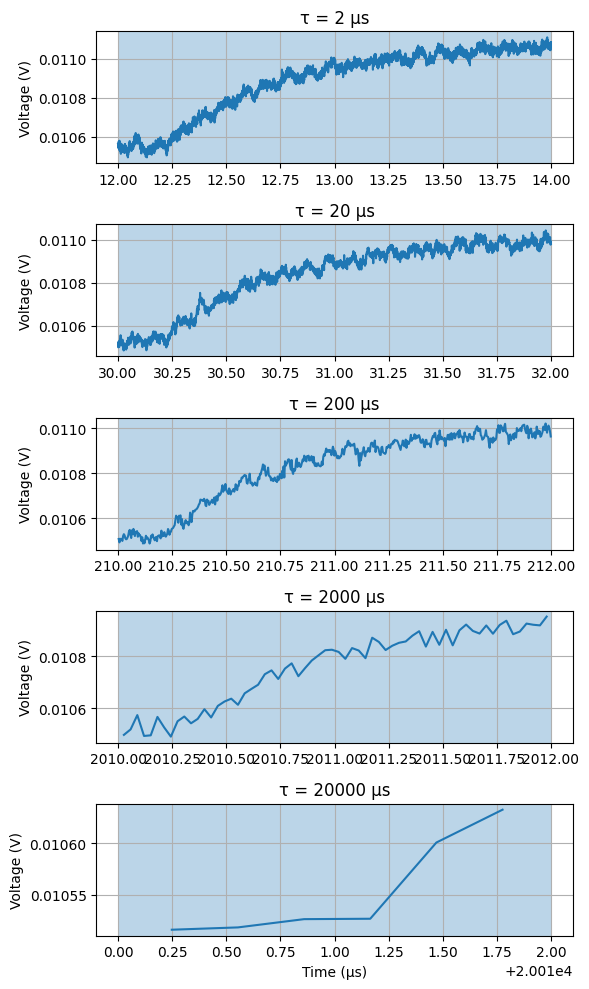

Ratios: [0.9819916096602183, 0.982885322711479, 0.9795136286017193, 0.9648643795483343, 0.8085141123331431]


In [42]:
# NO EDGE 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# dark times (µs)
list_darktime = [2, 20, 200, 2000, 20000]

# edge durations (seconds)
list_edge = [15e-9, 15e-9, 21e-9, 301e-9, 2e-6]

ratio_list = []

fig, ax = plt.subplots(len(list_darktime), 1, figsize=(6,10))


for i, t in enumerate(list_darktime):

    # load data
    df = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t * 1e-6
    edge = list_edge[i]

    # timing windows
    t0 = polarize_pulse_width + dark_time
    t1 = t0 + 2000e-9
    t2 = polarize_pulse_width/2
    t3 = t2 + 2000e-9

    # integration regions
    reading = df[(df["Time"] >= t0) & (df["Time"] < t1)]
    reference = df[(df["Time"] >= t2) & (df["Time"] < t3)]

    # integrate
    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    if reference_int != 0:
        ratio = reading_int / reference_int
    else:
        ratio = np.nan

    ratio_list.append(ratio)

    # plot only around the window
    margin = 0.3e-10
    window = df[(df["Time"] >= t0-margin) & (df["Time"] <= t1+margin)]

    ax[i].plot(window["Time"]*1e6, window["Voltage"], label="Waveform")

    # highlight integration regions
    ax[i].axvspan(t0*1e6, t1*1e6, alpha=0.3, label="Reading")
    # ax[i].axvspan(t2*1e6, t3*1e6, alpha=0.3, label="Reference")

    ax[i].set_title(f"τ = {t} µs")
    ax[i].set_ylabel("Voltage (V)")
    ax[i].grid(True)

ax[-1].set_xlabel("Time (µs)")

plt.tight_layout()
plt.show()

print("Ratios:", ratio_list)

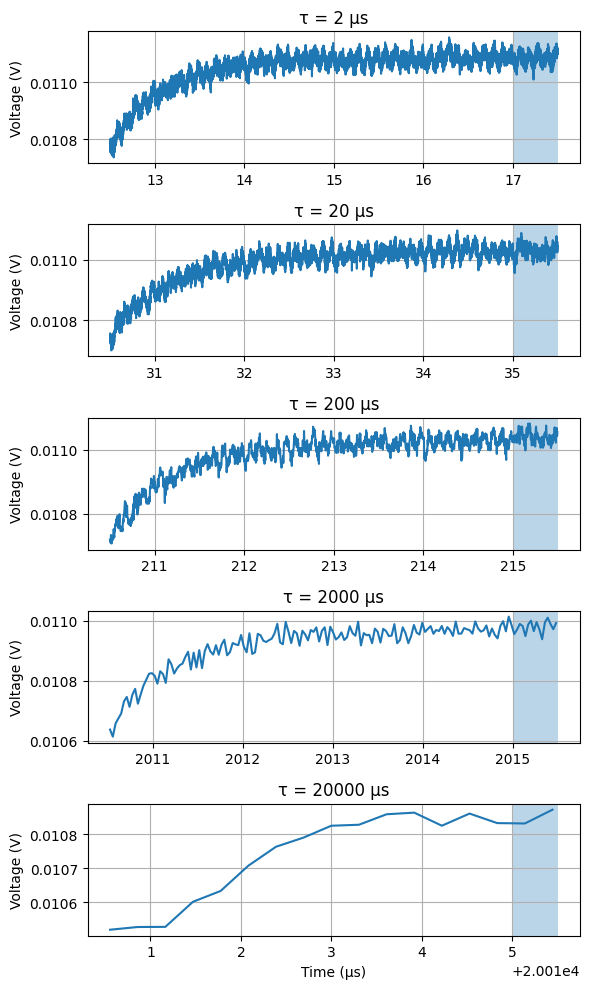

Ratios: [0.9577812024323971, 0.9610589910893476, 0.9586889111010796, 0.9606959251405212, 0.0]


In [45]:
# NO EDGE 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# dark times (µs)
list_darktime = [2, 20, 200, 2000, 20000]

# edge durations (seconds)
list_edge = [15e-9, 15e-9, 21e-9, 301e-9, 2e-6]

ratio_list = []

fig, ax = plt.subplots(len(list_darktime), 1, figsize=(6,10))


for i, t in enumerate(list_darktime):

    # load data
    df = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t * 1e-6
    edge = list_edge[i]

    # timing windows
    t0 = polarize_pulse_width + dark_time
    t1 = t0 + 500e-9
    t2 = t1 + polarize_pulse_width/2 - 500e-9
    t3 = t2 + 500e-9

    # integration regions
    reading = df[(df["Time"] >= t0) & (df["Time"] < t1)]
    reference = df[(df["Time"] >= t2) & (df["Time"] < t3)]

    # integrate
    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    if reference_int != 0:
        ratio = reading_int / reference_int
    else:
        ratio = np.nan

    ratio_list.append(ratio)

    # plot only around the window
    margin = 0.3e-10
    window = df[(df["Time"] >= t1-margin) & (df["Time"] <= t3+margin)]

    ax[i].plot(window["Time"]*1e6, window["Voltage"], label="Waveform")

    # highlight integration regions
    # ax[i].axvspan(t0*1e6, t1*1e6, alpha=0.3, label="Reading")
    ax[i].axvspan(t2*1e6, t3*1e6, alpha=0.3, label="Reference")

    ax[i].set_title(f"τ = {t} µs")
    ax[i].set_ylabel("Voltage (V)")
    ax[i].grid(True)

ax[-1].set_xlabel("Time (µs)")

plt.tight_layout()
plt.show()

print("Ratios:", ratio_list)

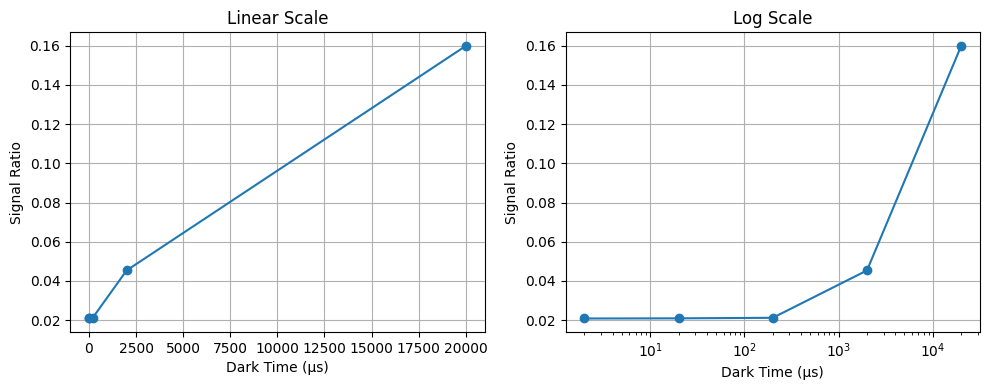

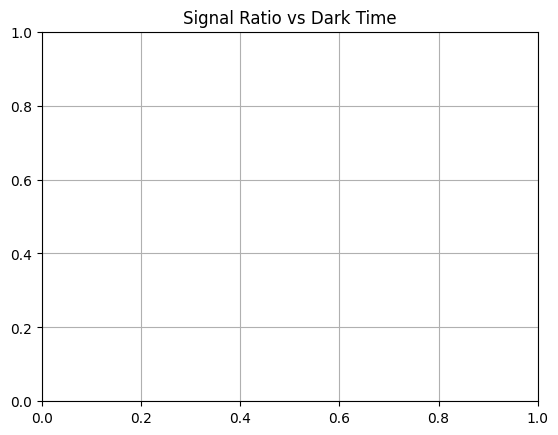

In [49]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10,4))

# Linear scale
ax[0].plot(list_darktime, ratio_list, marker='o')
ax[0].set_xlabel("Dark Time (µs)")
ax[0].set_ylabel("Signal Ratio")
ax[0].set_title("Linear Scale")
ax[0].grid(True)

# Log scale
ax[1].plot(list_darktime, ratio_list, marker='o')
ax[1].set_xscale("log")
ax[1].set_xlabel("Dark Time (µs)")
ax[1].set_ylabel("Signal Ratio")
ax[1].set_title("Log Scale")
ax[1].grid(True)

plt.tight_layout()
plt.show()
plt.title("Signal Ratio vs Dark Time")

plt.grid(True)

plt.show()

# 2 us

In [26]:
import pandas as pd
import numpy as np

df = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau 2us/averaged_waveform.csv")
df.columns = ["Time","Voltage"]

polarize_pulse_width = 10e-6
dark_time = t*1e-6
edge = 15e-9

t0 = edge + polarize_pulse_width + dark_time
t1 = t0 + 0.5*edge + 200e-9
t2 = t1 + polarize_pulse_width - 200e-9 + 0.5*edge

reading = df[(df["Time"] >= t0) & (df["Time"] < t1)]
# reference = df[(df["Time"] >= t1)]
reference = df[(df["Time"] >= t1) & (df["Time"] <t2) ]

reading_int = np.trapz(reading["Voltage"], reading["Time"])
reference_int = np.trapz(reference["Voltage"], reference["Time"])

ratio = reading_int / reference_int
print("Ratio:", ratio)

Ratio: nan


C:\Users\trina\AppData\Local\Temp\ipykernel_26856\2345779814.py:22: RuntimeWarning: invalid value encountered in scalar divide
  ratio = reading_int / reference_int


# 20 us

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau 20us/averaged_waveform.csv")
df.columns = ["Time","Voltage"]

polarize_pulse_width = 10e-6
dark_time = 20e-6


t0 = polarize_pulse_width + dark_time
t1 = t0 + 200e-9

reading = df[(df["Time"] >= t0) & (df["Time"] < t1)]
reference = df[df["Time"] >= t1]

reading_int = np.trapz(reading["Voltage"], reading["Time"])
reference_int = np.trapz(reference["Voltage"], reference["Time"])

ratio = reading_int / reference_int

print("Ratio:", ratio)

Ratio: 0.004572662950133712


# 200 us

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau 200us/averaged_waveform.csv")
df.columns = ["Time","Voltage"]

polarize_pulse_width = 10e-6
dark_time = 200e-6

t0 = polarize_pulse_width + dark_time
t1 = t0 + 200e-9

reading = df[(df["Time"] >= t0) & (df["Time"] < t1)]
reference = df[df["Time"] >= t1]

reading_int = np.trapz(reading["Voltage"], reading["Time"])
reference_int = np.trapz(reference["Voltage"], reference["Time"])

ratio = reading_int / reference_int

print("Ratio:", ratio)

Ratio: 0.0010006913128450927


# 2 ms

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau 2000us/averaged_waveform.csv")
df.columns = ["Time","Voltage"]

polarize_pulse_width = 10e-6
dark_time = 2000e-6

t0 = polarize_pulse_width + dark_time
t1 = t0 + 200e-9

reading = df[(df["Time"] >= t0) & (df["Time"] < t1)]
reference = df[df["Time"] >= t1]

reading_int = np.trapz(reading["Voltage"], reading["Time"])
reference_int = np.trapz(reference["Voltage"], reference["Time"])

ratio = reading_int / reference_int

print("Ratio:", ratio)

Ratio: 9.154275264091266e-05


# 20 ms

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau 20000us/averaged_waveform.csv")
df.columns = ["Time","Voltage"]

polarize_pulse_width = 10e-6
dark_time = 20000e-6

t0 = polarize_pulse_width + dark_time
t1 = t0 + 200e-9

reading = df[(df["Time"] >= t0) & (df["Time"] < t1)]
reference = df[df["Time"] >= t1]

reading_int = np.trapz(reading["Voltage"], reading["Time"])
reference_int = np.trapz(reference["Voltage"], reference["Time"])

ratio = reading_int / reference_int

print("Ratio:", ratio)

Ratio: 0.0


---

A = 31.181308521743603
B = -31.177980843447816
T1 = -171.4950260180974 seconds


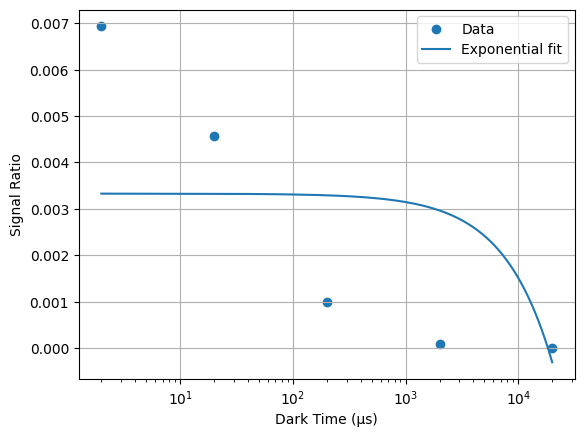

R(t) = 31.18131 + -31.17798 * exp(-t / -1.71495e+02)


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def exp_decay(t, A, B, T1):
    return A + B * np.exp(-t / T1)

x = np.array(list_darktime) * 1e-6   # convert µs → s
y = np.array(ratio_list)

params, _ = curve_fit(exp_decay, x, y)

A, B, T1 = params

print("A =", A)
print("B =", B)
print("T1 =", T1, "seconds")

x_fit = np.linspace(min(x), max(x), 500)
y_fit = exp_decay(x_fit, A, B, T1)

plt.figure()

plt.scatter(x*1e6, y, label="Data")
plt.plot(x_fit*1e6, y_fit, label="Exponential fit")

plt.xscale("log")

plt.xlabel("Dark Time (µs)")
plt.ylabel("Signal Ratio")

plt.legend()
plt.grid(True)

plt.show()

print(f"R(t) = {A:.5f} + {B:.5f} * exp(-t / {T1:.5e})")